# Multiclass vs. Multilabel Classification with SVM, Logistic Regression, and Neural Networks

## Goals
By the end of this notebook, you should be able to:

1. Distinguish **multiclass** classification from **multilabel** classification.
2. Train and evaluate:
   - **SVM**
   - **Logistic Regression**
   - **Neural Network**
3. Apply these models to:
   - **Multiclass classification**
   - **Multilabel classification**
4. Understand the role of:
   - **softmax**
   - **one-vs-rest (OvR)**
   - **sigmoid output units**
   - **binary cross-entropy**
   - **categorical cross-entropy**

---


## 1. Conceptual distinction

### Multiclass classification
Each sample belongs to **exactly one** class.

Examples:
- tumor type is **A**, **B**, or **C**
- iris species is **setosa**, **versicolor**, or **virginica**

Examples of targets:
- 0, 1, 2
- one-hot vectors like $[1,0,0]$, $[0,1,0]$, $[0,0,1]$

### Multilabel classification
Each sample may belong to **multiple classes at the same time**.

Examples:
- a gene may be associated with multiple pathways
- a biomedical abstract may have multiple topic tags
- an image may contain **dog**, **tree**, and **car**

Examples of targets:
- $[1,0,1,1]$
- $[0,1,0,0]$

### Key difference
- **Multiclass**: one sample → one class
- **Multilabel**: one sample → multiple possible labels

---


## 2. Imports

We will use:
- `scikit-learn` for SVM, logistic regression, and MLP
- `matplotlib` for plots
- synthetic datasets from `sklearn.datasets`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

np.random.seed(42)


## 3. Create a multiclass dataset

We first generate a synthetic dataset with **3 classes**.

This is a standard multiclass setting:
- each sample belongs to exactly one class
- the target is a single integer class label


In [2]:
X_mc, y_mc = make_classification(
    n_samples=900,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_repeated=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42,
)

X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.25, random_state=42, stratify=y_mc
)

print("Multiclass training shape:", X_mc_train.shape)
print("Multiclass test shape:", X_mc_test.shape)
print("Unique classes:", np.unique(y_mc_train))


Multiclass training shape: (675, 10)
Multiclass test shape: (225, 10)
Unique classes: [0 1 2]


## 4. Multiclass classification with Logistic Regression

In scikit-learn, multinomial logistic regression can be trained directly.

Conceptually:
- each class $k$ has a score
  $$
  z_k = w_k^T x + b_k
  $$
- softmax converts scores to probabilities
  $$
  P(y=k\mid x)=\frac{e^{z_k}}{\sum_j e^{z_j}}
  $$
- the cost function is **categorical cross-entropy**
  $$
  J = -\sum_{i=1}^N \sum_{k=1}^K y_{ik}\log p_{ik}
  $$

The gradient for class $k$ is driven by:
$$
\sum_{i=1}^N (p_{ik}-y_{ik})x_i
$$


In [4]:
logreg_mc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    ))
])

# multiclass classification is handled automatically.
logreg_mc.fit(X_mc_train, y_mc_train)
y_pred_logreg_mc = logreg_mc.predict(X_mc_test)

print("Multiclass Logistic Regression Accuracy:", accuracy_score(y_mc_test, y_pred_logreg_mc))
print()
print(classification_report(y_mc_test, y_pred_logreg_mc))


Multiclass Logistic Regression Accuracy: 0.9511111111111111

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        75
           1       0.95      0.99      0.97        74
           2       0.96      0.93      0.95        76

    accuracy                           0.95       225
   macro avg       0.95      0.95      0.95       225
weighted avg       0.95      0.95      0.95       225



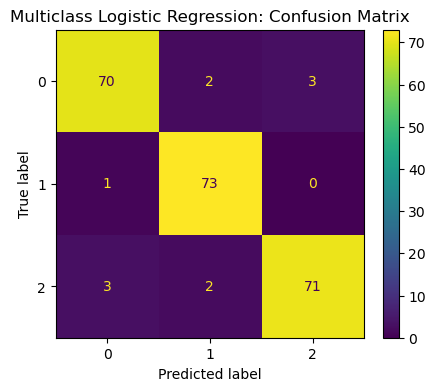

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_mc_test, y_pred_logreg_mc, ax=ax)
ax.set_title("Multiclass Logistic Regression: Confusion Matrix")
plt.show()


## 5. Multiclass classification with SVM

### Important idea
SVM is fundamentally a **binary margin-based classifier**.

To extend it to multiclass problems, common strategies include:
- **one-vs-rest (OvR)**
- **one-vs-one (OvO)**

Here we use an SVM classifier directly through scikit-learn. Internally, multiclass handling is managed automatically.

The SVM loss is based on the **hinge loss**, not cross-entropy.


In [6]:
svm_mc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

svm_mc.fit(X_mc_train, y_mc_train)
y_pred_svm_mc = svm_mc.predict(X_mc_test)

print("Multiclass SVM Accuracy:", accuracy_score(y_mc_test, y_pred_svm_mc))
print()
print(classification_report(y_mc_test, y_pred_svm_mc))


Multiclass SVM Accuracy: 0.96

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        75
           1       0.97      0.97      0.97        74
           2       0.97      0.95      0.96        76

    accuracy                           0.96       225
   macro avg       0.96      0.96      0.96       225
weighted avg       0.96      0.96      0.96       225



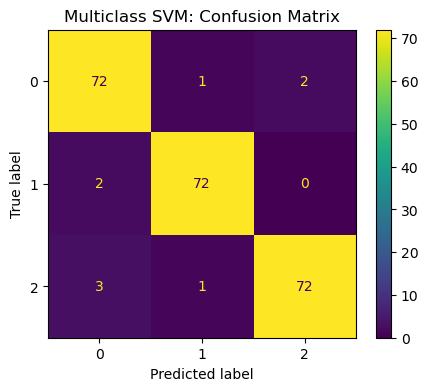

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_mc_test, y_pred_svm_mc, ax=ax)
ax.set_title("Multiclass SVM: Confusion Matrix")
plt.show()


## 6. Multiclass classification with a Neural Network

For multiclass neural networks:
- the output layer usually has **one neuron per class**
- the output activation is **softmax**
- the loss is **categorical cross-entropy**

In scikit-learn, `MLPClassifier` handles the optimization internally.


In [8]:
nn_mc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    ))
])

nn_mc.fit(X_mc_train, y_mc_train)
y_pred_nn_mc = nn_mc.predict(X_mc_test)

print("Multiclass Neural Network Accuracy:", accuracy_score(y_mc_test, y_pred_nn_mc))
print()
print(classification_report(y_mc_test, y_pred_nn_mc))


Multiclass Neural Network Accuracy: 0.9733333333333334

              precision    recall  f1-score   support

           0       0.99      0.95      0.97        75
           1       0.96      1.00      0.98        74
           2       0.97      0.97      0.97        76

    accuracy                           0.97       225
   macro avg       0.97      0.97      0.97       225
weighted avg       0.97      0.97      0.97       225



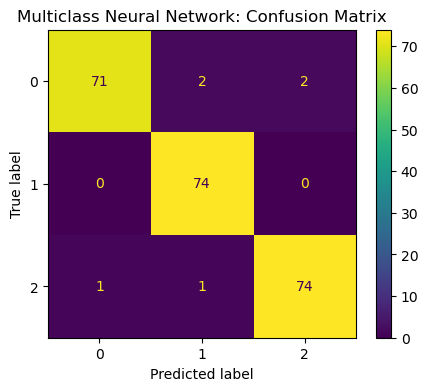

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_mc_test, y_pred_nn_mc, ax=ax)
ax.set_title("Multiclass Neural Network: Confusion Matrix")
plt.show()


## 7. Compare multiclass models

We summarize the multiclass results side by side.


In [10]:
multiclass_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Neural Network"],
    "Accuracy": [
        accuracy_score(y_mc_test, y_pred_logreg_mc),
        accuracy_score(y_mc_test, y_pred_svm_mc),
        accuracy_score(y_mc_test, y_pred_nn_mc),
    ],
    "Macro F1": [
        f1_score(y_mc_test, y_pred_logreg_mc, average="macro"),
        f1_score(y_mc_test, y_pred_svm_mc, average="macro"),
        f1_score(y_mc_test, y_pred_nn_mc, average="macro"),
    ],
    "Weighted F1": [
        f1_score(y_mc_test, y_pred_logreg_mc, average="weighted"),
        f1_score(y_mc_test, y_pred_svm_mc, average="weighted"),
        f1_score(y_mc_test, y_pred_nn_mc, average="weighted"),
    ]
})

multiclass_summary.sort_values("Macro F1", ascending=False)


,Model,Accuracy,Macro F1,Weighted F1
2,Neural Network,0.973333,0.973268,0.973239
1,SVM,0.960000,0.960114,0.960056
0,Logistic Regression,0.951111,0.951050,0.950961


## 8. Create a multilabel dataset

Now we move to **multilabel classification**.

Each sample can have multiple labels simultaneously.

We will generate a dataset where the target looks like:

- $[1,0,1,0]$
- $[0,1,1,1]$
- $[0,0,0,1]$

This is very different from multiclass classification.


In [12]:
X_ml, Y_ml = make_multilabel_classification(
    n_samples=1200,
    n_features=20,
    n_classes=4,
    n_labels=2,
    allow_unlabeled=False,
    random_state=42
)

X_ml_train, X_ml_test, Y_ml_train, Y_ml_test = train_test_split(
    X_ml, Y_ml, test_size=0.25, random_state=42
)

print("Multilabel training shape:", X_ml_train.shape)
print("Multilabel target shape:", Y_ml_train.shape)
print("First 5 multilabel targets:")
print(Y_ml_train[:5])


Multilabel training shape: (900, 20)
Multilabel target shape: (900, 4)
First 5 multilabel targets:
[[1 0 0 0]
 [1 0 1 1]
 [0 1 1 0]
 [0 1 1 1]
 [0 1 0 1]]


## 9. How multilabel classification is usually handled

In multilabel classification, we usually build **one binary classifier per label**.

For each label:
- predict 1 = label present
- predict 0 = label absent

This is naturally compatible with:
- **One-vs-Rest style decomposition**
- **sigmoid-like independent outputs**
- **binary cross-entropy** in neural networks

### Why softmax is not appropriate here
Softmax forces all class probabilities to sum to 1. That makes sense when exactly one class is correct, but not when multiple labels may all be correct at once.

For multilabel neural networks:
- output layer has one neuron per label
- each output uses a **sigmoid-like interpretation**
- loss is **binary cross-entropy**, summed over labels


## 10. Multilabel classification with Logistic Regression

We use `OneVsRestClassifier(LogisticRegression(...))`.

This means:
- one logistic regression model per label
- each model solves a binary classification problem


In [13]:
logreg_ml = Pipeline([
    ("scaler", StandardScaler()),
    ("model", OneVsRestClassifier(
        LogisticRegression(max_iter=2000, solver="lbfgs")
    ))
])

logreg_ml.fit(X_ml_train, Y_ml_train)
Y_pred_logreg_ml = logreg_ml.predict(X_ml_test)

print("Multilabel Logistic Regression")
print("Subset accuracy:", accuracy_score(Y_ml_test, Y_pred_logreg_ml))
print("Macro F1:", f1_score(Y_ml_test, Y_pred_logreg_ml, average="macro"))
print("Micro F1:", f1_score(Y_ml_test, Y_pred_logreg_ml, average="micro"))
print("Hamming loss:", hamming_loss(Y_ml_test, Y_pred_logreg_ml))


Multilabel Logistic Regression
Subset accuracy: 0.49333333333333335
Macro F1: 0.8439441347138468
Micro F1: 0.8471544715447155
Hamming loss: 0.15666666666666668


### Note on subset accuracy
For multilabel classification, **subset accuracy** is strict:
- a prediction is counted as correct only if **all labels** are correct for that sample

So subset accuracy may look lower than expected even when the model is fairly good.

That is why metrics such as:
- **micro F1**
- **macro F1**
- **Hamming loss**
are often more informative.


## 11. Multilabel classification with SVM

Again we use a one-vs-rest structure:
- one binary SVM per label


In [14]:
svm_ml = Pipeline([
    ("scaler", StandardScaler()),
    ("model", OneVsRestClassifier(
        LinearSVC(random_state=42, max_iter=5000)
    ))
])

svm_ml.fit(X_ml_train, Y_ml_train)
Y_pred_svm_ml = svm_ml.predict(X_ml_test)

print("Multilabel SVM")
print("Subset accuracy:", accuracy_score(Y_ml_test, Y_pred_svm_ml))
print("Macro F1:", f1_score(Y_ml_test, Y_pred_svm_ml, average="macro"))
print("Micro F1:", f1_score(Y_ml_test, Y_pred_svm_ml, average="micro"))
print("Hamming loss:", hamming_loss(Y_ml_test, Y_pred_svm_ml))


Multilabel SVM
Subset accuracy: 0.49666666666666665
Macro F1: 0.8457317942938722
Micro F1: 0.848780487804878
Hamming loss: 0.155


## 12. Multilabel classification with a Neural Network

For multilabel neural networks:
- one output unit per label
- each output is interpreted independently
- target vector may contain multiple 1s
- training is based on **binary cross-entropy**

`MLPClassifier` in scikit-learn can be used for multilabel problems when the target is a binary indicator matrix.


In [15]:
nn_ml = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    ))
])

nn_ml.fit(X_ml_train, Y_ml_train)
Y_pred_nn_ml = nn_ml.predict(X_ml_test)

print("Multilabel Neural Network")
print("Subset accuracy:", accuracy_score(Y_ml_test, Y_pred_nn_ml))
print("Macro F1:", f1_score(Y_ml_test, Y_pred_nn_ml, average="macro"))
print("Micro F1:", f1_score(Y_ml_test, Y_pred_nn_ml, average="micro"))
print("Hamming loss:", hamming_loss(Y_ml_test, Y_pred_nn_ml))


Multilabel Neural Network
Subset accuracy: 0.55
Macro F1: 0.85464007331015
Micro F1: 0.8531353135313532
Hamming loss: 0.14833333333333334


## 13. Compare multilabel models


In [16]:
multilabel_summary = pd.DataFrame({
    "Model": ["Logistic Regression (OvR)", "SVM (OvR)", "Neural Network"],
    "Subset Accuracy": [
        accuracy_score(Y_ml_test, Y_pred_logreg_ml),
        accuracy_score(Y_ml_test, Y_pred_svm_ml),
        accuracy_score(Y_ml_test, Y_pred_nn_ml),
    ],
    "Macro F1": [
        f1_score(Y_ml_test, Y_pred_logreg_ml, average="macro"),
        f1_score(Y_ml_test, Y_pred_svm_ml, average="macro"),
        f1_score(Y_ml_test, Y_pred_nn_ml, average="macro"),
    ],
    "Micro F1": [
        f1_score(Y_ml_test, Y_pred_logreg_ml, average="micro"),
        f1_score(Y_ml_test, Y_pred_svm_ml, average="micro"),
        f1_score(Y_ml_test, Y_pred_nn_ml, average="micro"),
    ],
    "Hamming Loss": [
        hamming_loss(Y_ml_test, Y_pred_logreg_ml),
        hamming_loss(Y_ml_test, Y_pred_svm_ml),
        hamming_loss(Y_ml_test, Y_pred_nn_ml),
    ]
})

multilabel_summary.sort_values("Micro F1", ascending=False)


,Model,Subset Accuracy,Macro F1,Micro F1,Hamming Loss
2,Neural Network,0.550000,0.854640,0.853135,0.148333
1,SVM (OvR),0.496667,0.845732,0.848780,0.155000
0,Logistic Regression (OvR),0.493333,0.843944,0.847154,0.156667


## 14. Inspect a few multilabel predictions

This helps build intuition.

Each row contains:
- true labels
- predicted labels


In [17]:
preview_df = pd.DataFrame({
    "True labels": [list(row) for row in Y_ml_test[:10]],
    "Pred (LogReg)": [list(row) for row in Y_pred_logreg_ml[:10]],
    "Pred (SVM)": [list(row) for row in Y_pred_svm_ml[:10]],
    "Pred (NN)": [list(row) for row in Y_pred_nn_ml[:10]],
})
preview_df


,True labels,Pred (LogReg),Pred (SVM),Pred (NN)
0,"[1, 1, 1, 1]","[0, 1, 0, 1]","[0, 1, 0, 1]","[0, 1, 0, 1]"
1,"[1, 1, 1, 1]","[1, 1, 0, 0]","[1, 1, 0, 0]","[1, 1, 0, 0]"
2,"[0, 0, 1, 0]","[0, 0, 1, 0]","[0, 0, 1, 0]","[0, 0, 1, 0]"
3,"[1, 0, 1, 0]","[1, 0, 1, 0]","[1, 0, 1, 0]","[1, 0, 1, 0]"
4,"[1, 1, 1, 1]","[1, 1, 0, 0]","[1, 1, 0, 0]","[1, 1, 1, 0]"
5,"[0, 1, 1, 0]","[1, 1, 1, 0]","[1, 1, 1, 0]","[1, 1, 1, 1]"
6,"[0, 0, 0, 1]","[0, 1, 0, 1]","[0, 1, 0, 1]","[0, 1, 0, 1]"
7,"[1, 1, 1, 0]","[1, 1, 1, 1]","[1, 1, 1, 1]","[1, 1, 1, 1]"
8,"[0, 1, 0, 0]","[0, 1, 0, 0]","[0, 1, 0, 0]","[0, 1, 0, 0]"
9,"[1, 1, 0, 0]","[1, 1, 1, 0]","[1, 1, 1, 0]","[1, 1, 1, 0]"


## 15. Summary: when to use what

### Multiclass classification
Use when each sample belongs to exactly one class.

Common approaches:
- **Logistic regression + softmax**
- **SVM with multiclass strategy**
- **Neural network + softmax**

Typical losses:
- logistic regression / neural network: **categorical cross-entropy**
- SVM: **hinge loss**

### Multilabel classification
Use when each sample may have multiple labels simultaneously.

Common approaches:
- **One-vs-Rest logistic regression**
- **One-vs-Rest SVM**
- **Neural network with one output per label**

Typical losses:
- logistic regression / neural network: **binary cross-entropy per label**
- SVM: **binary hinge loss per label**

---


## 16. Key conceptual table

| Setting | Target structure | Output idea | Typical probability function | Typical loss |
|---|---|---|---|---|
| Multiclass | exactly one class | one score per class | softmax | categorical cross-entropy |
| Multilabel | multiple possible labels | one independent output per label | sigmoid per label | binary cross-entropy |

---


## 17. Exercises

1. Modify the multiclass example from 3 classes to 5 classes.
2. Increase label overlap in the multilabel dataset and see how metrics change.
3. For the neural network, try:
   - one hidden layer
   - deeper networks
   - different numbers of neurons
4. Compare:
   - macro F1
   - micro F1
   - weighted F1
5. Explain in words why softmax is unsuitable for multilabel classification.

---


## 18. Optional discussion questions

1. Why does softmax force competition among classes?
2. Why is sigmoid more natural for multilabel outputs?
3. Why can subset accuracy be too harsh in multilabel classification?
4. Why is SVM not naturally probabilistic in the same way as logistic regression?
5. In a bioinformatics application, which problems are likely multiclass and which are likely multilabel?

---
